# New idea

# Data
+ https://docs.google.com/spreadsheets/d/1QpclNCfzhjdLaEzORqihMpsB98K_51hc/edit?pli=1&gid=796299748#gid=796299748

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle
import re

In [13]:
# color palette 
cividis_colors = ['#fff1a2ff', '#e1d6aaff', '#a3a3a5ff', '#65749aff', '#00449fff']
cividis_3 = [cividis_colors[2]] +[cividis_colors[3]] + [cividis_colors[4]]

# this one is color blind friendly 
okabe_ito_colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

In [14]:
df = pd.read_excel('../../data/cc20_us_02052025_website.xlsx')

# View the first 5 rows
(df)


,CCN20,Dist Code,State Postal Abbreviation,Total Population,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,...,"Sold, not occupied - Vacant housing units","For seasonal, recreational, or occasional use - Vacant housing units",All other vacants - Vacant housing units,Homeowner vacancy rate (percent) - Vacancy rates,Rental vacancy rate (percent) - Vacancy rates,Occupied housing units - Housing Tenure,Owner-occupied housing units - Housing Tenure,Renter-occupied housing units - Housing Tenure,Diversity Ratio,Dependency Ratio
0,101001,101,AL,55599,3155,3250,3638,3515,3228,3269,...,171,1241,1319,0.25,0.16,21088,15615,5473,0,0.675678
1,101002,101,AL,67916,4254,4607,5022,4759,3901,4028,...,39,62,573,0.14,0.05,25038,19972,5066,0,0.674334
2,101003,101,AL,34347,1947,2148,2355,2380,2080,2063,...,38,105,520,0.17,0.08,13267,10240,3027,0,0.723987
3,101004,101,AL,45525,2485,2895,3271,3310,2652,2419,...,107,681,620,0.21,0.12,17129,12965,4164,0,0.722018
4,101005,101,AL,36757,2183,2206,2416,2195,1935,2249,...,146,220,1217,0.22,0.14,14499,10112,4387,0,0.729741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,2683,3045,3154,3145,2912,2992,...,106,169,473,0.86,13.29,19289,12183,7106,0,0.677171
7403,5600009,5600,WY,44159,2364,2659,2843,2570,2076,2211,...,140,931,1070,1.01,15.43,18346,13694,4652,0,0.778095
7404,5600010,5600,WY,54207,3806,4184,4539,3717,2881,3441,...,90,586,761,0.58,14.26,20765,15337,5428,0,0.672952
7405,5600011,5600,WY,56457,3246,3500,3610,3101,3477,4286,...,63,159,502,0.41,6.53,24915,15429,9486,0,0.660012


+ now to make people

In [15]:
df.rename(columns={'Dist Code': 'DC', 'State Postal Abbreviation': 'State'}, inplace=True)

In [16]:
[col for col in df.columns if re.search(r'Pop$', col)]

['Under 5 years - Tot Pop',
 '5 to 9 years - Tot Pop',
 '10 to 14 years - Tot Pop',
 '15 to 19 years - Tot Pop',
 '20 to 24 years - Tot Pop',
 '25 to 29 years - Tot Pop',
 '30 to 34 years - Tot Pop',
 '35 to 39 years - Tot Pop',
 '40 to 44 years - Tot Pop',
 '45 to 49 years - Tot Pop',
 '50 to 54 years - Tot Pop',
 '55 to 59 years - Tot Pop',
 '60 to 64 years - Tot Pop',
 '65 to 69 years - Tot Pop',
 '70 to 74 years - Tot Pop',
 '75 to 79 years - Tot Pop',
 '80 to 84 years - Tot Pop',
 '85 years and over - Tot Pop',
 '16 years and over - Tot Pop',
 '18 years and over - Tot Pop',
 '21 years and over - Tot Pop',
 '62 years and over - Tot Pop',
 '65 years and over  - Tot Pop']

In [17]:
df = df.copy()

df_new = df.assign(
    ageGroup_under18=lambda x: x['Total Population'] - x['18 years and over - Tot Pop'],
    ageGroup_over65=lambda x: x['65 years and over  - Tot Pop'],
    ageGroup_18_65=lambda x: (
        x['18 years and over - Tot Pop'] - x['65 years and over  - Tot Pop']
    )
)

df_new

,CCN20,DC,State,Total Population,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,...,Homeowner vacancy rate (percent) - Vacancy rates,Rental vacancy rate (percent) - Vacancy rates,Occupied housing units - Housing Tenure,Owner-occupied housing units - Housing Tenure,Renter-occupied housing units - Housing Tenure,Diversity Ratio,Dependency Ratio,ageGroup_under18,ageGroup_over65,ageGroup_18_65
0,101001,101,AL,55599,3155,3250,3638,3515,3228,3269,...,0.25,0.16,21088,15615,5473,0,0.675678,12503,9916,33180
1,101002,101,AL,67916,4254,4607,5022,4759,3901,4028,...,0.14,0.05,25038,19972,5066,0,0.674334,17265,10088,40563
2,101003,101,AL,34347,1947,2148,2355,2380,2080,2063,...,0.17,0.08,13267,10240,3027,0,0.723987,8153,6271,19923
3,101004,101,AL,45525,2485,2895,3271,3310,2652,2419,...,0.21,0.12,17129,12965,4164,0,0.722018,11021,8067,26437
4,101005,101,AL,36757,2183,2206,2416,2195,1935,2249,...,0.22,0.14,14499,10112,4387,0,0.729741,8385,7122,21250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,2683,3045,3154,3145,2912,2992,...,0.86,13.29,19289,12183,7106,0,0.677171,10704,7583,27005
7403,5600009,5600,WY,44159,2364,2659,2843,2570,2076,2211,...,1.01,15.43,18346,13694,4652,0,0.778095,9513,9811,24835
7404,5600010,5600,WY,54207,3806,4184,4539,3717,2881,3441,...,0.58,14.26,20765,15337,5428,0,0.672952,14928,6877,32402
7405,5600011,5600,WY,56457,3246,3500,3610,3101,3477,4286,...,0.41,6.53,24915,15429,9486,0,0.660012,12313,10134,34010


In [18]:
age_bracket_cols = [col for col in df_new.columns if re.search(r'^ageGroup', col)]
age_bracket_cols

['ageGroup_under18', 'ageGroup_over65', 'ageGroup_18_65']

In [19]:
# this needs to be a dictionary -- 
# takes 

# e.g. age 
df_age = df_new[['CCN20', 'DC', 'State']].join(df_new[age_bracket_cols])
df_age

,CCN20,DC,State,ageGroup_under18,ageGroup_over65,ageGroup_18_65
0,101001,101,AL,12503,9916,33180
1,101002,101,AL,17265,10088,40563
2,101003,101,AL,8153,6271,19923
3,101004,101,AL,11021,8067,26437
4,101005,101,AL,8385,7122,21250
...,...,...,...,...,...,...
7402,5600008,5600,WY,10704,7583,27005
7403,5600009,5600,WY,9513,9811,24835
7404,5600010,5600,WY,14928,6877,32402
7405,5600011,5600,WY,12313,10134,34010


for sake of exposiiton, let's do CCN 101001

In [20]:
ccn20_number = 101001

In [21]:
# creates dictionary with each thing to do a lookup
ccn20_dict = df[['CCN20', 'DC', 'State']].groupby('CCN20').apply(
    lambda g:g.to_dict(orient='records')
).to_dict()

In [22]:
# aggregating bases on cc, congressional, dist 
def group_function(df, group):
    nested_dict = df.groupby(group)[age_bracket_cols].sum().to_dict(orient='index')
    return nested_dict

In [23]:
# grouping! 
df_state_graph = group_function(df_age, 'State')
df_cd_graph = group_function(df_age, 'DC')

In [25]:
ccn20_dict[ccn20_number]

[{'DC': 101, 'State': 'AL'}]

In [26]:
df_cd_graph

{101: {'ageGroup_under18': 165109,
  'ageGroup_over65': 140086,
  'ageGroup_18_65': 412559},
 102: {'ageGroup_under18': 164360,
  'ageGroup_over65': 124720,
  'ageGroup_18_65': 428674},
 103: {'ageGroup_under18': 158363,
  'ageGroup_over65': 127114,
  'ageGroup_18_65': 432277},
 104: {'ageGroup_under18': 167505,
  'ageGroup_over65': 135691,
  'ageGroup_18_65': 414558},
 105: {'ageGroup_under18': 161961,
  'ageGroup_over65': 119738,
  'ageGroup_18_65': 436055},
 106: {'ageGroup_under18': 170071,
  'ageGroup_over65': 117239,
  'ageGroup_18_65': 430445},
 107: {'ageGroup_under18': 156216,
  'ageGroup_over65': 120135,
  'ageGroup_18_65': 441403},
 200: {'ageGroup_under18': 179388,
  'ageGroup_over65': 95185,
  'ageGroup_18_65': 458818},
 401: {'ageGroup_under18': 147634,
  'ageGroup_over65': 168835,
  'ageGroup_18_65': 478142},
 402: {'ageGroup_under18': 173312,
  'ageGroup_over65': 183574,
  'ageGroup_18_65': 437726},
 403: {'ageGroup_under18': 234408,
  'ageGroup_over65': 66063,
  'ageGr

In [27]:
ccn20_record = ccn20_dict[ccn20_number][0]
df_cd_graph[ccn20_record['DC']]
df_state_graph[ccn20_record['State']]

{'ageGroup_under18': 1143585,
 'ageGroup_over65': 884723,
 'ageGroup_18_65': 2995971}

/var/folders/r1/ygmywd652zq_jmsr6k782p_00000gn/T/ipykernel_79829/3597849257.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_dc.show()


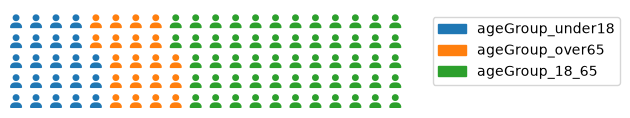

In [30]:
fig_dc = plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=df_cd_graph[ccn20_record['DC']],
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10, 
  cmap_name="tab10"
)
fig_dc.show()

In [31]:
df_state_graph[ccn20_record['State']]

{'ageGroup_under18': 1143585,
 'ageGroup_over65': 884723,
 'ageGroup_18_65': 2995971}

/var/folders/r1/ygmywd652zq_jmsr6k782p_00000gn/T/ipykernel_79829/416734623.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_state.show()


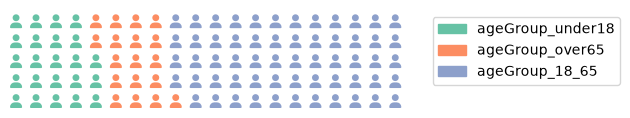

In [32]:
fig_state = plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=df_state_graph[ccn20_record['State']],
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10
)
fig_state.show()

In [33]:
def prep_dict(df, cc_number): 
    new_df = df.loc[df_age['CCN20'] == cc_number].drop(columns=['CCN20','DC', 'State']).to_dict(orient = 'records')
    return new_df[0]

/var/folders/r1/ygmywd652zq_jmsr6k782p_00000gn/T/ipykernel_79829/116682242.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cc.show()


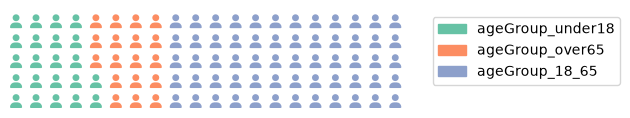

In [34]:
fig_cc = plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=prep_dict(df_age, ccn20_number),
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10
)
fig_cc.show()

In [35]:
okabe_ito_colors[0:2]

['#E69F00', '#56B4E9']

In [61]:
def make_full_chart(ccn_number, df_age, df_cd_graph, df_state_graph):

    fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)


    ## cc
    Waffle.make_waffle(
        ax=ax1,
        rows=5,
        columns=20,
        values=prep_dict(df_age, ccn_number),
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                            'ncol':3, 'fontsize':8},
                    starting_location='NW',
        icons='user',
        font_size=12, 
        colors = okabe_ito_colors[0:3]
    )

    ## dc
    Waffle.make_waffle(
        ax=ax2,
        rows=5,
        columns=20,
        values=df_cd_graph[ccn20_record['DC']],
        icons='user',
        font_size=12,
        colors = okabe_ito_colors[0:3]
    )

    ## state
    Waffle.make_waffle(
        ax=ax3,
        rows=5,
        columns=20,
        values=df_state_graph[ccn20_record['State']],
        icons='user',
        font_size=12, 
        colors = okabe_ito_colors[0:3]
    )


    ax1.text(-0.05, 0.5, 'Congressional\n Community', transform=ax1.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)
    ax2.text(-0.05, 0.5, 'Congressional\n District', transform=ax2.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)
    ax3.text(-0.05, 0.5, 'State', transform=ax3.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)

    plt.subplots_adjust(left=0.25)  # make room so labels aren't cut off

    # Remove legends from ax2 and ax3, keep only ax1's
    ax2.get_legend().remove()
    ax3.get_legend().remove()

    fig.suptitle('If your community was 100 people...by age')
    plt.show()
    
    return plt


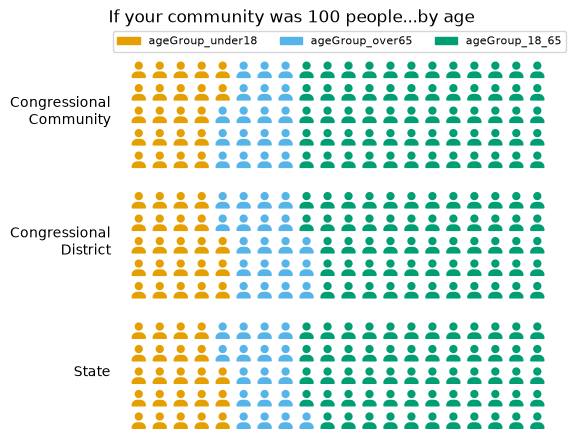

In [62]:
fig = make_full_chart(ccn20_number, df_age, df_cd_graph, df_state_graph)

+ If it might be better to do just cc and comparisons

In [72]:
[not_used] + [okabe_ito_colors[1]] + [not_used]

['lightgrey', '#56B4E9', 'lightgrey']

/var/folders/r1/ygmywd652zq_jmsr6k782p_00000gn/T/ipykernel_79829/102323836.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cc.show()


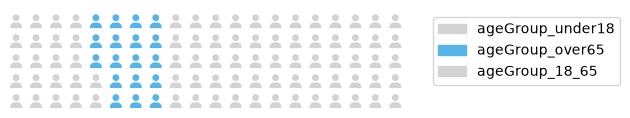

In [73]:
not_used = 'lightgrey'

fig_cc = plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=prep_dict(df_age, ccn20_number),
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10, 
  colors = [not_used] + [okabe_ito_colors[1]] + [not_used]
)
fig_cc.show()

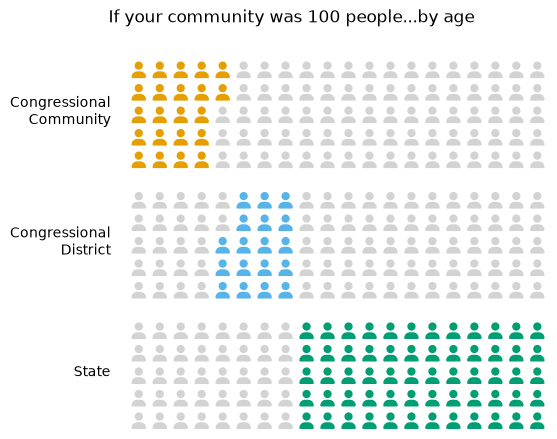

In [74]:
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)


## cc
Waffle.make_waffle(
    ax=ax1,
    rows=5,
    columns=20,
    values=prep_dict(df_age, ccn20_number),
    legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                        'ncol':3, 'fontsize':8},
                starting_location='NW',
    icons='user',
    font_size=12, 
    colors = [okabe_ito_colors[0]] + [not_used]  + [not_used]
)

## dc
Waffle.make_waffle(
    ax=ax2,
    rows=5,
    columns=20,
    values=prep_dict(df_age, ccn20_number),
    legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                        'ncol':3, 'fontsize':8},
                starting_location='NW',
    icons='user',
    font_size=12, 
    colors = [not_used] + [okabe_ito_colors[1]] + [not_used]
)

## state
Waffle.make_waffle(
    ax=ax3,
    rows=5,
    columns=20,
    values=prep_dict(df_age, ccn20_number),
    legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                        'ncol':3, 'fontsize':8},
                starting_location='NW',
    icons='user',
    font_size=12, 
    colors = [not_used] + [not_used] + [okabe_ito_colors[2]] 
)


ax1.text(-0.05, 0.5, 'Congressional\n Community', transform=ax1.transAxes,
        fontsize=10, ha='right', va='center', rotation=0)
ax2.text(-0.05, 0.5, 'Congressional\n District', transform=ax2.transAxes,
        fontsize=10, ha='right', va='center', rotation=0)
ax3.text(-0.05, 0.5, 'State', transform=ax3.transAxes,
        fontsize=10, ha='right', va='center', rotation=0)

plt.subplots_adjust(left=0.25)  # make room so labels aren't cut off

# Remove legends from ax2 and ax3, keep only ax1's
ax1.get_legend().remove()
ax2.get_legend().remove()
ax3.get_legend().remove()

fig.suptitle('If your community was 100 people...by age')
plt.show()